# <span style="color:green"> Script for segmentation in slicer and definition of cylindrical 3D ROI

## <span style="color:black"> Black: stages in code
## <span style="color:red"> RED = ACTION REQUIRED
## <span style="color:Silver"> Silver = data resulting from action (also can be changed)
## <span style="color:blue"> Blue = notes

## <span style="color:blue"> make sure the CT scans are from the side so that sagital would be top (coronal = frontal)

# Load libraries

In [1]:
from pathlib import Path
import slicer
import vtk
import pyvista as pv
import math
import numpy as np
import JupyterNotebooksLib as slicernb
import os
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import pyslicer as ps

# <span style="color:red"> User input

# Papermill parameters to be changed

In [3]:
# Specify the directory of nrrd_file
nrrd_file = 'xxx'


# if thresholding_method = manual → assign threshold values for void_max and hexa_min ( at 1.2- Build cylinder model)
# if thresholding_method = automatic → choose a method [HUANG/INTERMODES/ ISO_DATA/KITTLER_ILLINGWORTH/LI/MAXIMUM_ENTROPY/MOMENTS/OTSU/RENYI_ENTROPY/SHANBHAG/TRIANGLE/YEN]

thresholding_method = "xx"  # "automatic" or "manual"

method_1 = 'xx' # for automatic thresholding
method_2 = 'xx' # for automatic thresholding

void_max = 1 # for manual thresholding
hexa_min = 2 # for manual thresholding


# Dimensions of the cylindrical ROI
cylinder_height = 1 #mm 
cylinder_radius = 0.5 #mm 

# Define your markup 
markup = 'XX'


# Preparing directories

In [4]:
# Specify the directory of cylinder file
cylinder_outputfile = 'cylinder_ROI.stl'

# Specify the parent path
path = Path(nrrd_file)
parentpath = os.path.join(path.parent.absolute(), markup)

# Create the new folder if it doesn't exist
if not os.path.exists(parentpath):
    os.makedirs(parentpath)

# Specify the directory of Specifications file 
Specifications_file_path = os.path.join(parentpath, "User_Specifications.txt")

In [5]:
#add extension to line markup
markup_file_path = parentpath + '.mrk.json'


# Prepare 3dSlicer and Import CT data

## Import .nrrd file

In [6]:
# Load the NRRD file
volume_node = slicer.util.loadVolume(nrrd_file)

## 1.2- Build cylinder model

In [7]:
# Load the markup file
markups_node = slicer.util.loadMarkups(markup_file_path)

# ROI Cylinder properties: specify dimensions of the model

Sandwiching cylinder properties

In [8]:
lineListNode = slicer.util.getNode(markup)

In [9]:
point1 = vtk.vtkVector3d(0,0,0)
lineListNode.GetNthControlPointPosition(0,point1)

point2 = vtk.vtkVector3d(0,0,0)
lineListNode.GetNthControlPointPosition(1,point2)

In [10]:
# arc tangent of in radians
angle = math.atan2(point2[2] - point1[2], point2[0] - point1[0])

In [11]:
center_cylinder = [point1[0] + cylinder_radius * math.cos(angle) + np.sign(point1[2] - point2[2]) * np.sign(math.cos(angle)) * cylinder_height/2 * abs(math.sin(angle)),
                   point1[1],
                   point1[2] + cylinder_radius * math.sin(angle) + np.sign(math.cos(angle)) * cylinder_height/2 * math.cos(angle)]

In [12]:
cylinder_direction = [np.sign(point1[2] - point2[2]) * np.sign(math.cos(angle)) * abs(math.sin(angle)), 
                      0,
                      abs(math.cos(angle))]

## Create cylinder

In [13]:
cylinder = pv.Cylinder(center=center_cylinder, direction=cylinder_direction,
                            radius=cylinder_radius, height=cylinder_height)
cylinderNode = slicer.modules.models.logic().AddModel(cylinder)

## Save cylinder as .stl file

In [14]:
slicer.util.exportNode(cylinderNode, parentpath + "/" + cylinder_outputfile)

True

## Save variables

In [15]:
# Variables to save
Specifications_type = "General_specifications_high-quality"


# Combine variables into a matrix
specifications = {
    "\n\nSpecifications": Specifications_type,
    "microCT_file": nrrd_file,
    "cylinder_height": cylinder_height,
    "cylinder_radius": cylinder_radius,

}

# create (overwrite) the file in append mode
with open(Specifications_file_path, "a") as file:
    # Write each variable as "variable_name: variable"
    for name, value in specifications.items():
        file.write(f"{name}: {value}\n")


# <span style="color:green"> Creating model out of CT scans inside cylinder ROI

## Load cylinder stl file as volume model

In [16]:
cylinder_filepath = str(parentpath) + '/cylinder_ROI.stl'

In [17]:
outputVolumeSpacingMm = volume_node.GetSpacing()
# Read model
inputModel = slicer.util.loadModel(cylinder_filepath)

# Get the bounds of the imported model
bounds = np.zeros(6)
inputModel.GetBounds(bounds)

# Calculate the output volume size based on the specified spacing
imageSize = [int((bounds[axis * 2 + 1] - bounds[axis * 2]) / outputVolumeSpacingMm[axis]) + 1 for axis in range(3)]

# Calculate the output volume origin based on the model bounds
imageOrigin = [bounds[axis * 2] for axis in range(3)]

# Create an empty image volume within the model bounds
imageData = vtk.vtkImageData()
imageData.SetDimensions(imageSize)
imageData.SetOrigin(imageOrigin)
imageData.SetSpacing(outputVolumeSpacingMm)
imageData.AllocateScalars(vtk.VTK_UNSIGNED_CHAR, 1)
imageData.GetPointData().GetScalars().Fill(0)

# Create a reference volume node with the image data and set spacing
referenceVolumeNode = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLScalarVolumeNode")
referenceVolumeNode.SetName("temp_volume")  # Set the name of the volume
referenceVolumeNode.SetAndObserveImageData(imageData)
referenceVolumeNode.SetSpacing(outputVolumeSpacingMm)
referenceVolumeNode.CreateDefaultDisplayNodes()

# Convert model to labelmap within the reference volume bounds
seg = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLSegmentationNode")
seg.SetReferenceImageGeometryParameterFromVolumeNode(referenceVolumeNode)
slicer.modules.segmentations.logic().ImportModelToSegmentationNode(inputModel, seg)
seg.CreateBinaryLabelmapRepresentation()


True

## Visualize histograms for thresholding

In [18]:
volumeArray = slicer.util.arrayFromVolume(volume_node)
histogram = np.histogram(volumeArray, bins=50)

In [19]:
# get the values of the histogram (y-axis) and the bins edges (x-axis)
hist_values, bin_edges = histogram

# Find peaks location in the histogram
peaks, _ = find_peaks(hist_values)

# Get the values of the peaks
peak_values = hist_values[peaks]

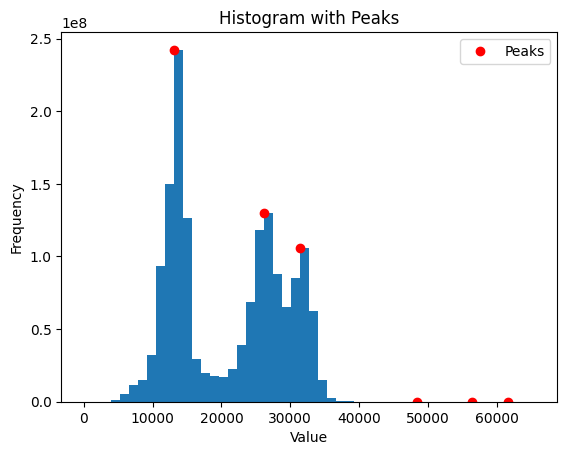

In [20]:
# Plot the histogram with peaks
plt.figure()
plt.bar(bin_edges[:-1], hist_values, width=np.diff(bin_edges), align='edge')
plt.plot(bin_edges[peaks], peak_values, 'ro', label='Peaks')
plt.legend()
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram with Peaks')


# Save the histogram plot to the specified folder and filename
filename = os.path.join(parentpath, "thresholding_histogram_with_peaks.png")
plt.savefig(filename)

plt.show()

# Close the figure to prevent displaying an empty plot
plt.close()


In [21]:
void_min = np.min(bin_edges) # minimum intensity from histogram
hexa_max = np.max(bin_edges) # maximum intesity from histogram

Plotting the histogram and the thresholds set manually.
Plotting using matplotlib from [tutorial](https://github.com/Slicer/SlicerNotebooks/blob/master/01_Data_loading_and_display.ipynb)

## Thresholding w.r.t. manual or automatic method

In [22]:
if thresholding_method == "automatic":
    import ast

    # File path
    parentpath = Path(parentpath)  # Convert string to Path object
    file_path = os.path.join(parentpath.parent, "thresholding/automatic_thresholding.txt")
    
    # Initialize dictionaries to store thresholds
    thresholds_1 = {}
    thresholds_2 = {}
    
    # Read the entire file content
    with open(file_path, 'r') as file:
        content = file.read()
    
    # Extract thresholds_1 dictionary
    start_1 = content.find("thresholds_1:") + len("thresholds_1:")
    end_1 = content.find("thresholds_2:") if "thresholds_2:" in content else len(content)
    thresholds_1_str = content[start_1:end_1].strip()
    
    # Extract thresholds_2 dictionary
    start_2 = content.find("thresholds_2:") + len("thresholds_2:")
    thresholds_2_str = content[start_2:].strip()
    
    # Convert the strings to dictionaries
    thresholds_1 = ast.literal_eval(thresholds_1_str)
       
    thresholds_2 = ast.literal_eval(thresholds_2_str)
    
    # Extract the values for 'MOMENTS'
    threshold_1 = thresholds_1.get(method_1)
    threshold_2 = thresholds_2.get(method_2)


    # use first method to threshold void max (first peak)
    void_max = method_1 + " threshold: " + str(threshold_1)
    print(void_max)
    
    # use second method to threshold hexa min (second peak)
    hexa_min = method_2 + " threshold: " + str(threshold_2)
    print(hexa_min)
    

In [23]:
# Variables to save
Specifications_type = "Thresholding_specifications"


# Combine variables into a matrix
specifications = {
    "\n\nSpecifications": Specifications_type,
    "thresholding_method": thresholding_method,
    "void_min_threshold": void_min,
    "void_max_threshold":void_max,
    "hexa_min_threshold":hexa_min,
    "hexa_max_threshold":hexa_max
}

# create (overwrite) the file in append mode
with open(Specifications_file_path, "a") as file:
    # Write each variable as "variable_name: variable"
    for name, value in specifications.items():
        file.write(f"{name}: {value}\n")


In [24]:
if thresholding_method == "automatic":
    void_max = threshold_1
    hexa_min = threshold_2
    
segmentsFromHounsfieldUnits = {
    "void": [void_min, void_max],
    "hexa": [hexa_min, hexa_max]
}

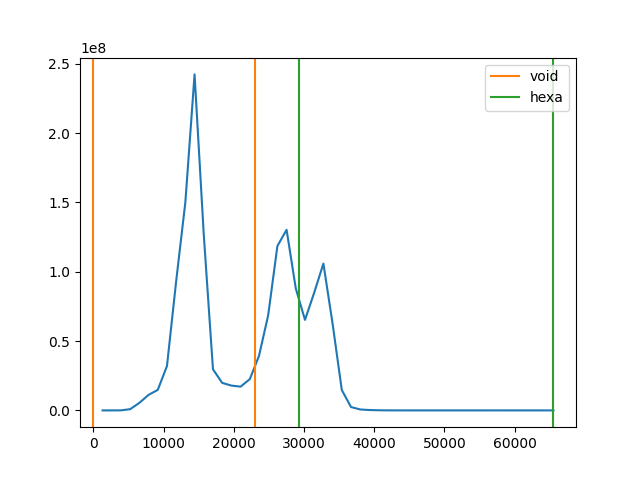

In [25]:
try:
  import matplotlib
except ModuleNotFoundError:
  slicer.util.pip_install('matplotlib')
  import matplotlib

import matplotlib.colors as mcolors  

matplotlib.use('Agg')

# Get a volume from SampleData and compute its histogram
import numpy as np
histogram = np.histogram(volumeArray, bins=50)

# Show a plot using matplotlib
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
ax.plot(histogram[1][1:], histogram[0].astype(float))

cmap = list(mcolors.TABLEAU_COLORS.values())
i=1
for key in segmentsFromHounsfieldUnits:
    thresh = segmentsFromHounsfieldUnits[key]
    ax.axvline(thresh[0], color=cmap[i], label=key)
    ax.axvline(thresh[1], color=cmap[i])
    i += 1

plt.legend(loc='upper right')

slicernb.MatplotlibDisplay(plt)

## save histogram

In [27]:
try:
    plt.savefig(parentpath / 'thresholding_histogram_regions.png')
except TypeError:
    parentpath = Path(parentpath)
    plt.savefig(parentpath / 'thresholding_histogram_regions.png')


## Create temporary segment editor to get access to effects

In [36]:
segmentEditorWidget = slicer.qMRMLSegmentEditorWidget()
segmentEditorWidget.setMRMLScene(slicer.mrmlScene)
segmentEditorNode = slicer.mrmlScene.AddNewNodeByClass("vtkMRMLSegmentEditorNode")
segmentEditorWidget.setMRMLSegmentEditorNode(segmentEditorNode)
segmentEditorWidget.setSegmentationNode(seg)
segmentEditorWidget.setMasterVolumeNode(volume_node)

## Create segments by thresholding

In [37]:
# Get the bounds of the mask model
maskBounds = np.zeros(6)
inputModel.GetBounds(maskBounds)

# Set the mask segment and mask mode
segmentEditorNode.SetMaskSegmentID(inputModel.GetID())
segmentEditorNode.SetMaskMode(1)  # Set mask mode to INSIDE

for segmentName in segmentsFromHounsfieldUnits:
    thresholdMin = segmentsFromHounsfieldUnits[segmentName][0]
    thresholdMax = segmentsFromHounsfieldUnits[segmentName][1]
    
    # Create segment
    addedSegmentID = seg.GetSegmentation().AddEmptySegment(segmentName)
    segmentEditorNode.SetSelectedSegmentID(addedSegmentID)
    
    # Fill by thresholding
    segmentEditorWidget.setActiveEffectByName("Threshold")
    effect = segmentEditorWidget.activeEffect()
    effect.setParameter("MinimumThreshold", str(thresholdMin))
    effect.setParameter("MaximumThreshold", str(thresholdMax))
    effect.self().onApply()


# Operations on segments

## Merge void and hexa segments

In [38]:
segmentName = 'pores'

addedSegmentID = seg.GetSegmentation().AddEmptySegment(segmentName)
segmentEditorNode.SetSelectedSegmentID(addedSegmentID)

## Rename all Nodes and Segments to remove "_#" 

In [39]:
# Iterate over all nodes in the scene
for node in slicer.mrmlScene.GetNodes():
    # Check if the node is a model, segmentation node, or other types as needed
    if node.IsA('vtkMRMLSegmentationNode'):
        segmentation_node = node
        # Get the current name of the segmentation node
        current_seg_node_name = segmentation_node.GetName()
        
        # Check if the name ends with "_#" where # is a number
        if '_' in current_seg_node_name and current_seg_node_name.split('_')[-1].isdigit():
            # Remove the "_#" suffix
            new_seg_node_name = '_'.join(current_seg_node_name.split('_')[:-1])
            
            # Set the new name for the segmentation node
            segmentation_node.SetName(new_seg_node_name)
            
        # Iterate over segments within the segmentation node
        for segment_index in range(segmentation_node.GetSegmentation().GetNumberOfSegments()):
            # Get the current segment name
            current_segment_name = segmentation_node.GetSegmentation().GetNthSegment(segment_index).GetName()

            # Check if the segment name ends with "_#" where # is a number
            if '_' in current_segment_name and current_segment_name.split('_')[-1].isdigit():
                # Remove the "_#" suffix
                new_segment_name = '_'.join(current_segment_name.split('_')[:-1])

                # Set the new name for the segment
                segmentation_node.GetSegmentation().GetNthSegment(segment_index).SetName(new_segment_name)
    
    elif node.IsA('vtkMRMLModelNode'):
        # Check if the model name ends with "_#" where # is a number
        current_model_name = node.GetName()
        if '_' in current_model_name and current_model_name.split('_')[-1].isdigit():
            # Remove the "_#" suffix
            new_model_name = '_'.join(current_model_name.split('_')[:-1])
            
            # Set the new name for the model node
            node.SetName(new_model_name)


Check [SegmentEditorLogicalEffect.py](https://github.com/Slicer/Slicer/blob/b0e0361be4f42aad2e5bb52142d9e0ed7df9d393/Modules/Loadable/Segmentations/EditorEffects/Python/SegmentEditorLogicalEffect.py#L275)

In [40]:
# Logical operators
segmentEditorWidget.setActiveEffectByName("Logical operators")
effect = segmentEditorWidget.activeEffect()

Add ```void``` segment to ```pores```

<span style="color:blue"> Running the effect:
<span style="color:blue"> The logical operation is set via strings
<span style="color:blue"> 'COPY', 'UNION', 'INTERSECT', 'SUBTRACT', 'INVERT', 'CLEAR', 'FILL'

<span style="color:blue"> (see: https://apidocs.slicer.org/master/SegmentEditorLogicalEffect_8py_source.html)  

In [41]:
operation = "UNION"
segment_to_add = "void"

effect.setParameter("Operation", operation) # change the operation here
effect.setParameter("ModifierSegmentID", segment_to_add)
effect.self().onApply()

Add ```hexa``` segment to ```pores```

In [42]:
operation = "UNION"
segment_to_add = "hexa"

effect.setParameter("Operation", operation) # change the operation here
effect.setParameter("ModifierSegmentID", segment_to_add)
effect.self().onApply()

## Grow segment

In [43]:
# Get the segment ID of the "pores" segment
segmentationNode = seg.GetSegmentation()
segmentID = segmentationNode.GetSegmentIdBySegmentName("pores")

# Set the active segment to "pores"
segmentEditorNode.SetSelectedSegmentID(segmentID)

# Set the active effect to "Margin"
segmentEditorWidget.setActiveEffectByName("Margin")
effect = segmentEditorWidget.activeEffect()

# Set the margin value

effect.setParameter("MarginSizeMm", str(outputVolumeSpacingMm[0]))

# Apply the effect
effect.self().onApply()


Check [SegmentEditorMarginEffect](https://github.com/Slicer/Slicer/blob/b0e0361be4f42aad2e5bb52142d9e0ed7df9d393/Modules/Loadable/Segmentations/EditorEffects/Python/SegmentEditorMarginEffect.py)

## Export models from segmentations

Export model nodes from segmentation node [source](https://slicer.readthedocs.io/en/latest/developer_guide/script_repository.html#export-model-nodes-from-segmentation-node)

In [44]:
segmentationNode = slicer.util.getNode("Segmentation")  # Replace "Segmentation" with the actual name of your segmentation node
segmentId = segmentationNode.GetSegmentation().GetSegmentIdBySegmentName("pores")

if segmentId:
    shNode = slicer.mrmlScene.GetSubjectHierarchyNode()
    exportFolderItemId = shNode.CreateFolderItem(shNode.GetSceneItemID(), "Segments")
    
    # Export only the "pores" segment
    slicer.modules.segmentations.logic().ExportSegmentsToModels(segmentationNode, [segmentId], exportFolderItemId)
else:
    print("Segment 'pores' not found in the segmentation.")


# Perform operations on the pore model

In [45]:
modelNode = slicer.util.getNode("pores")
modelPV = pv.PolyData(modelNode.GetPolyData())

## Export pore model to .STL file

In [47]:
filename_output = '0_pores_void.stl'

modelPV.save(parentpath / filename_output)

## Fill holes 

In [48]:
max_hole = 1000

fill_modelPV = modelPV.fill_holes(hole_size = max_hole)

In [49]:
fil_modelNode = slicer.modules.models.logic().AddModel(fill_modelPV)
fil_modelNode.SetName('filled_pores')

## Export pore model to .STL file

In [51]:
filename_output = '1_pores_fill-holes.stl'

fill_modelPV.save(parentpath / filename_output)

## Save cleaning specifications

In [52]:
# Variables to save
Specifications_type = "used_3dslicer_cleaning_specifications"

# if any of these variables was not used then name assign "not applied" to it
try:
    # Check if the variable is defined
    minimumIslandSize
except NameError:
    # If the variable is not defined, assign it a default value
    minimumIslandSize = "not applicable"

try:
    # Check if the variable is defined
    iterations
except NameError:
    # If the variable is not defined, assign it a default value
    iterations = "not applicable"

try:
    # Check if the variable is defined
    relax_factor
except NameError:
    # If the variable is not defined, assign it a default value
    relax_factor = "not applicable"

try:
    # Check if the variable is defined
    max_hole
except NameError:
    # If the variable is not defined, assign it a default value
    max_hole = "not applicable"

    
    

note = "\tThresholds for void: between 0 (min value) - and the first valley between 2 first max peaks \n\tThresholds for hexa: between the first valley after these peaks and before the first new peak - till 255 (max value)"
    

# Combine variable names and values into a dictionary
specifications = {
    "CT_threshold_segments": segmentsFromHounsfieldUnits,
    "*": note,
    "\n\nSpecifications": Specifications_type,
    "Removing_small_islands-minimumIslandSize": minimumIslandSize,
    "Surface_smoothing-iterations": iterations,
    "Surface_smoothing-relax_factor": relax_factor,
    "Fill_holes-max_hole": max_hole,
}

# Open the file in write mode
with open(Specifications_file_path, "a") as file:
    # Write each variable as "variable_name: variable"
    for name, value in specifications.items():
        file.write(f"{name}: {value}\n")